# Running MEEP Simulations

[MEEP](https://meep.readthedocs.io/) is an open-source FDTD electromagnetic simulator. This notebook demonstrates using the `gsim.meep` API to run an S-parameter simulation on a photonic Y-branch.

**Requirements:**

- UBC PDK: `uv pip install ubcpdk`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from UBC PDK

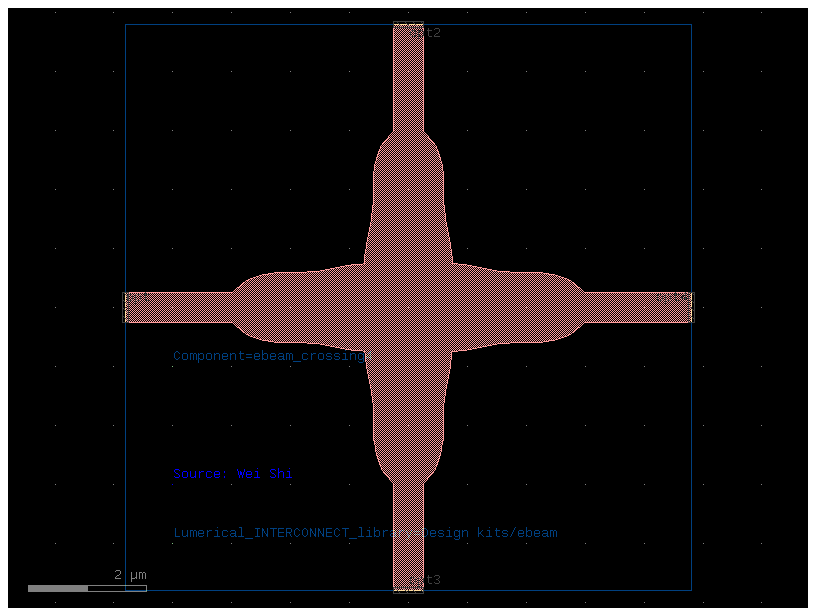

In [1]:
from ubcpdk import PDK, cells

PDK.activate()

c = cells.ebeam_crossing4()

c

### Configure and run simulation

In [2]:
from gsim import meep
from gsim.common.stack import get_stack
from gsim.meep.models.api import Material

stack = get_stack()  # auto-detects active PDK

sim = meep.Simulation()

sim.geometry(component=c, stack=stack)
sim.materials = {
    "si": Material(refractive_index=3.47),
    "SiO2": Material(refractive_index=1.44),
}
sim.source(port="o1", wavelength=1.55, wavelength_span=0.04)
sim.monitors = ["o1", "o2", "o3", "o4"]
sim.domain(pml=1.0, margin_x=0.5, margin_y=0.5, z_ref="stack", extend_into_pml=True)
sim.solver(resolution=20, save_animation=True, verbose_interval=5.0)
sim.num_freqs = 21
sim.solver.stop_when_energy_decayed()

print(sim.validate_config())

Stack validation: PASSED
Warnings:
  - Stopping: energy_decay (dt=20.0, decay_by=0.01, cap=2000.0)


/Users/vahid/doplaydo/gsim/src/gsim/meep/simulation.py:2046: FutureWarning: Use of domain.z_ref is deprecated and will be removed in a future release; replace it with domain.z_bounds=(-3.5, 3.4000000000000004).
  result = self.build_config()


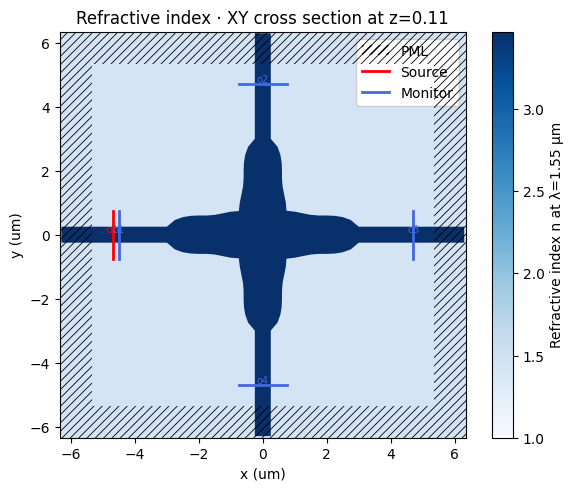

In [3]:
sim.plot_2d(slices="z")

### Run simulation on cloud

In [4]:
# Run on GDSFactory+ cloud
result = sim.run(check_cache=True)

  meep-e5f67e93  failed  0m 22s


RuntimeError: Simulation failed before producing an exit code
Status: failed
Reason: Task failed to start
Details: CannotPullContainerError: failed to tag image '999685767753.dkr.ecr.us-west-2.amazonaws.com/simulations/meep@sha256:73270bd2933a6378bb47b26dd3e6be899881891fb71ffe810bdfe2941ac53bc0' as '999685767753.dkr.ecr.us-west-2.amazonaws.com/simulations/meep:latest': Error response from daemon: open /var/lib/docker/image/overlay2/imagedb/metadata/sha256/317adf97c7fb95c5cbd3d2b869e69a05c81c26db6f2b36f24e0cf55e79974fca/.tmp-lastUpdated3276602542: no space left on device

In [ ]:
result.plot_interactive()

In [ ]:
result.plot_interactive(phase=True)

In [ ]:
result.show_animation()